In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/features_v2.csv")

In [2]:
target = "points"

drop_cols = [
    "raceId",
    "driverId",
    "constructorId",
    "date",
    "positionOrder",
    "avgLapTime_s",
    "points"
]

features = [col for col in df.columns if col not in drop_cols]

train = df[df["year"] < 2020]
test  = df[df["year"] >= 2020]

X_train = train[features]
X_test  = test[features]

y_train = train[target]
y_test  = test[target]

In [3]:
rf_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

base_preds = rf_base.predict(X_test)

base_r2 = r2_score(y_test, base_preds)
base_mae = mean_absolute_error(y_test, base_preds)

print("Baseline R2:", base_r2)
print("Baseline MAE:", base_mae)

Baseline R2: 0.6033261252687754
Baseline MAE: 3.0678212134132385


In [4]:
ablation_features_1 = [f for f in features if f != "constructor_form_avg"]

X_train_ab1 = train[ablation_features_1]
X_test_ab1  = test[ablation_features_1]

rf_ab1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_ab1.fit(X_train_ab1, y_train)

ab1_preds = rf_ab1.predict(X_test_ab1)

ab1_r2 = r2_score(y_test, ab1_preds)
ab1_mae = mean_absolute_error(y_test, ab1_preds)

print("Ablation 1 R2:", ab1_r2)
print("Ablation 1 MAE:", ab1_mae)

Ablation 1 R2: 0.6054670808161773
Ablation 1 MAE: 3.06156978152996


In [5]:
ablation_features_2 = [f for f in features if f != "driver_form_avg"]

X_train_ab2 = train[ablation_features_2]
X_test_ab2  = test[ablation_features_2]

rf_ab2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_ab2.fit(X_train_ab2, y_train)

ab2_preds = rf_ab2.predict(X_test_ab2)

ab2_r2 = r2_score(y_test, ab2_preds)
ab2_mae = mean_absolute_error(y_test, ab2_preds)

print("Ablation 2 R2:", ab2_r2)
print("Ablation 2 MAE:", ab2_mae)

Ablation 2 R2: 0.5939086763057975
Ablation 2 MAE: 3.115499745827403


In [6]:
results = pd.DataFrame({
    "Model": [
        "Baseline (All Features)",
        "Without constructor_form_avg",
        "Without driver_form_avg"
    ],
    "R2": [
        base_r2,
        ab1_r2,
        ab2_r2
    ],
    "MAE": [
        base_mae,
        ab1_mae,
        ab2_mae
    ]
})

results

,Model,R2,MAE
0,Baseline (All Features),0.603326,3.067821
1,Without constructor_form_avg,0.605467,3.061570
2,Without driver_form_avg,0.593909,3.115500


An ablation study was conducted to evaluate the contribution of engineered features. Removing driver_form_avg resulted in a measurable decline in performance (R² drop of ~0.01), indicating its importance. Conversely, removing constructor_form_avg slightly improved performance, suggesting redundancy with other performance-related variables. This indicates that driver-level form is a stronger predictive signal than aggregated constructor form.

Removing constructor_form_avg - That feature was NOT helping.
                              - It may be redundant or slightly noisy

Removing driver_form_avg - has meaningful predictive contribution.

1. Constructor form is likely captured indirectly through:
Grid position
Rolling points
Driver form
Other correlated variables

2. Driver form is a stronger signal for predicting constructor points.
Which actually makes intuitive sense in F1.


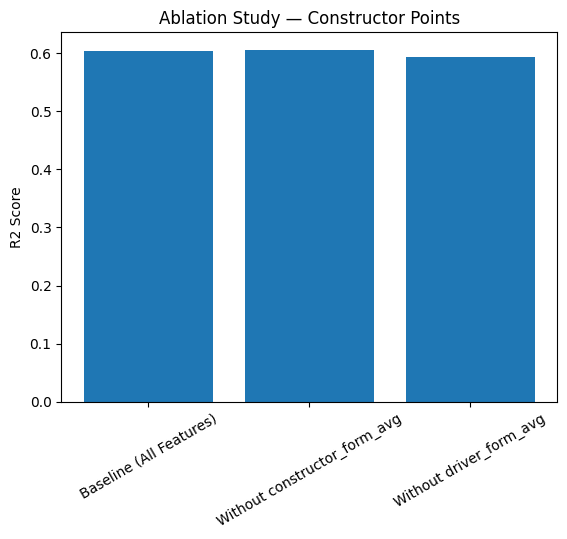

In [7]:
plt.figure()
plt.bar(results["Model"], results["R2"])
plt.xticks(rotation=30)
plt.ylabel("R2 Score")
plt.title("Ablation Study — Constructor Points")
plt.show()